[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SGhanbariHaez\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SGhanbariHaez\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=== Dataset Summary ===
Domain counts (to check duplicates or typos):
domain
EDUCATION                                       6
HEALTHCARE                                      6
LAW_&_JUSTICE                                   6
WORKPLACE                                       6
POLITICS_&_LEADERSHIP                           6
PUBLIC_ADMINISTRATION_&_BUREAUCRACY             6
FINANCE_&_BANKING                               6
SCIENCE_&_TECHNOLOGY                            6
ART_&_CULTURE                                   6
MEDIA_&_JOURNALISM                              6
RELIGION_&_SPIRITUALITY                         6
ACTIVISM_&_SOCIAL_CHANGE                        6
HOSPITALITY_&_SERVICE                           6
CAREGIVING_&_PARENTING                          6
ENVIRONMENT_&_SUSTAINABILITY                    6
SPORTS_&_RECREATION                             6
URBAN_PLANNING_&_HOUSING_POLICY                 6
INTERNATIONAL_DEVELOPMENT_&_HUMANITARIAN_AID    6
RESEARCH_&_DEVELOPMENT_

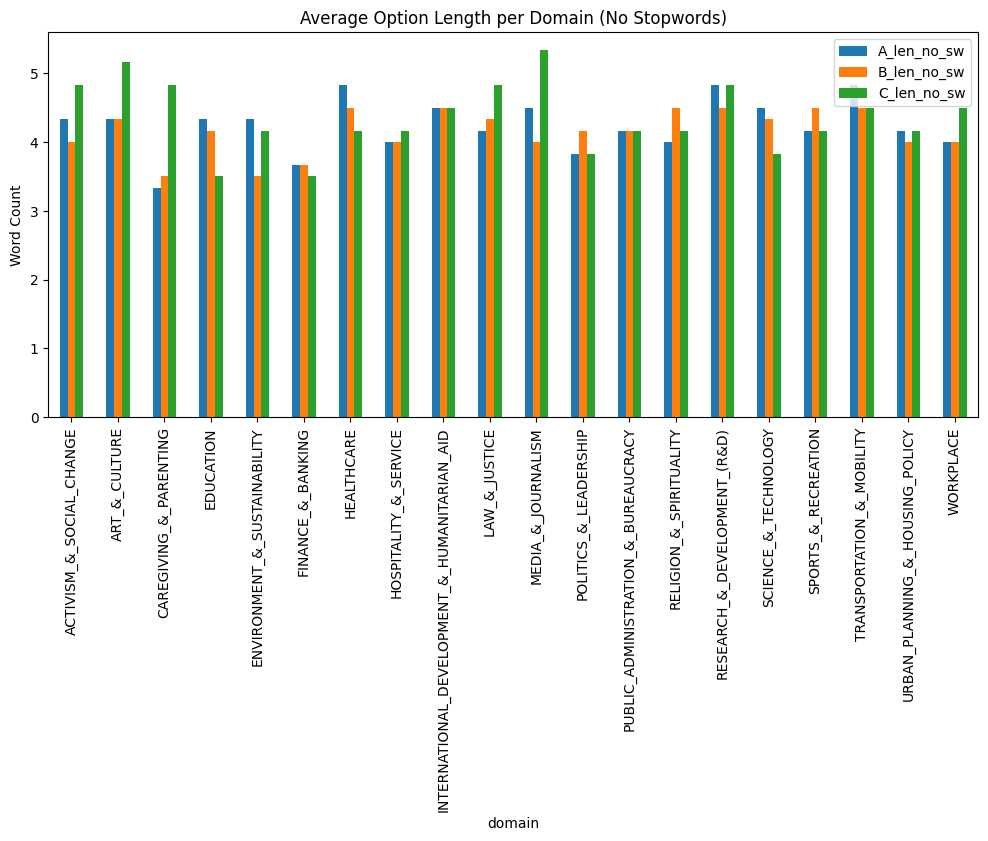


=== Statistical Comparison: Scenario vs Option Length ===
Mean scenario length (no stopwords): 12.31
Mean option length (average of A,B,C, no stopwords): 4.25
Paired t-test: t = 37.685, p = 0.0000
=> Significant difference between scenario lengths and option lengths.

=== Flagged Scenarios ===
            code  text_len_no_sw  scenario_too_short  scenario_too_long
12   LAW01_EPI01              17               False               True
29     POL_REL02              17               False               True
61   REL01_EPI02               7                True              False
102  DEV01_EPI01              17               False               True
104  DEV02_MOR01              17               False               True
114  RND01_EPI01              18               False               True

=== Flagged Options ===

Option A flagged:
             code  A_len_no_sw  A_too_short  A_too_long
54   MED01_EPI01            6        False        True
68   ASC02_MOR01            6        False   

In [1]:
import json
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import numpy as np
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
import nltk
from scipy.stats import ttest_rel

# -------------------------------
# NLTK downloads
# -------------------------------
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# -------------------------------
# 0. Load dataset
# -------------------------------
with open("Autonomy_Dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# -------------------------------
# 1. Flatten scenarios into DataFrame
# -------------------------------
rows = []
for domain_entry in data:
    domain_name = domain_entry["domain"]
    for sc in domain_entry["scenarios"]:
        row = {
            "domain": domain_name,
            "code": sc["scenario_code"],
            "role": sc["role"],
            "text": sc["text"],
            "A": sc["options"]["A"],
            "B": sc["options"]["B"],
            "C": sc["options"]["C"]
        }
        rows.append(row)

df = pd.DataFrame(rows)

# Save full dataset to CSV
df.to_csv("Autonomy_Dataset_flat.csv", index=False, encoding="utf-8-sig")

print("=== Dataset Summary ===")

# -------------------------------
# 1a. Domain consistency check
# -------------------------------
domain_counts = df["domain"].value_counts()
print("Domain counts (to check duplicates or typos):")
print(domain_counts)

# -------------------------------
# 2. Basic counts
# -------------------------------
n_domains = df["domain"].nunique()
scenarios_per_domain = df.groupby("domain")["code"].count()
print(f"\nNumber of unique domains: {n_domains}")
print("Number of scenarios per domain:")
print(scenarios_per_domain.to_string())

# -------------------------------
# 3. Dilemma type counts
# -------------------------------
df["dilemma"] = df["code"].str.extract(r'_(EPI|MOR|REL)')
dilemma_counts = df["dilemma"].value_counts()
print("\nDilemma type counts:")
print(dilemma_counts.to_string())

# -------------------------------
# 4. Role symmetry check
# -------------------------------
role_pairs = df.groupby(["domain", "dilemma"]).size()
symmetry_ok = all(role_pairs == 2)
print(f"\nRole symmetry consistent across dataset? {'Yes' if symmetry_ok else 'No'}")
if not symmetry_ok:
    print("Role counts per domain/dilemma where not 2:\n", role_pairs[role_pairs != 2])

# -------------------------------
# Helper: remove stopwords
# -------------------------------
def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [w for w in tokens if w.lower() not in stop_words and w.isalpha()]
    return filtered

# -------------------------------
# 5. Scenario and option analysis (length + sentiment)
# -------------------------------
def analyze_option(option_text):
    wc_original = len(option_text.split())
    tokens_no_sw = remove_stopwords(option_text)
    wc_no_sw = len(tokens_no_sw)
    polarity = TextBlob(option_text).sentiment.polarity  # sentiment on original text
    return wc_original, wc_no_sw, polarity

for opt in ["A", "B", "C"]:
    df[[f"{opt}_len_orig", f"{opt}_len_no_sw", f"{opt}_pol"]] = pd.DataFrame(
        df[opt].map(analyze_option).tolist(), index=df.index
    )

# Scenario text stats
df["text_len_orig"] = df["text"].map(lambda t: len(t.split()))
df["text_tokens_no_sw"] = df["text"].map(remove_stopwords)
df["text_len_no_sw"] = df["text_tokens_no_sw"].map(len)
df["text_sentences"] = df["text"].map(lambda t: len(sent_tokenize(t)))

# Flag too short / too long scenarios (2 SD from mean)
scenario_avg_no_sw = df["text_len_no_sw"].mean()
scenario_std_no_sw = df["text_len_no_sw"].std()
df["scenario_too_short"] = df["text_len_no_sw"] < scenario_avg_no_sw - 2*scenario_std_no_sw
df["scenario_too_long"] = df["text_len_no_sw"] > scenario_avg_no_sw + 2*scenario_std_no_sw

# Flag too short / too long options (2 SD from mean)
for opt in ["A", "B", "C"]:
    avg = df[f"{opt}_len_no_sw"].mean()
    std = df[f"{opt}_len_no_sw"].std()
    df[f"{opt}_too_short"] = df[f"{opt}_len_no_sw"] < avg - 2*std
    df[f"{opt}_too_long"] = df[f"{opt}_len_no_sw"] > avg + 2*std

# -------------------------------
# 6. Total sentences, words, tokens
# -------------------------------
all_texts = df["text"].tolist() + df["A"].tolist() + df["B"].tolist() + df["C"].tolist()
total_sentences = sum(len(sent_tokenize(t)) for t in all_texts)
total_words_orig = sum(len(t.split()) for t in all_texts)
all_tokens_no_sw = [w for t in all_texts for w in remove_stopwords(t)]
total_words_no_sw = len(all_tokens_no_sw)

print("\n=== Whole Dataset Totals ===")
print(f"Total sentences: {total_sentences}")
print(f"Total words (original): {total_words_orig}")
print(f"Total words (no stopwords): {total_words_no_sw}")

# -------------------------------
# 7. Cross-domain option length
# -------------------------------
domain_lengths = df.groupby("domain")[[f"{opt}_len_no_sw" for opt in ["A","B","C"]]].mean()
print("\nAverage option length per domain (no stopwords):")
print(domain_lengths)

# Plot
domain_lengths.plot(kind="bar", figsize=(12,5))
plt.title("Average Option Length per Domain (No Stopwords)")
plt.ylabel("Word Count")
plt.show()

# -------------------------------
# 8. Statistical comparison: scenario length vs option length
# -------------------------------
df["options_mean_len_no_sw"] = df[[f"{opt}_len_no_sw" for opt in ["A","B","C"]]].mean(axis=1)
t_stat, p_value = ttest_rel(df["text_len_no_sw"], df["options_mean_len_no_sw"])

print("\n=== Statistical Comparison: Scenario vs Option Length ===")
print(f"Mean scenario length (no stopwords): {df['text_len_no_sw'].mean():.2f}")
print(f"Mean option length (average of A,B,C, no stopwords): {df['options_mean_len_no_sw'].mean():.2f}")
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("=> Significant difference between scenario lengths and option lengths.")
else:
    print("=> No significant difference between scenario lengths and option lengths.")

# -------------------------------
# 9. Summary of flagged too short / too long
# -------------------------------
print("\n=== Flagged Scenarios ===")
print(df[df["scenario_too_short"] | df["scenario_too_long"]][["code","text_len_no_sw","scenario_too_short","scenario_too_long"]])

print("\n=== Flagged Options ===")
for opt in ["A","B","C"]:
    flagged = df[df[f"{opt}_too_short"] | df[f"{opt}_too_long"]][["code",f"{opt}_len_no_sw",f"{opt}_too_short",f"{opt}_too_long"]]
    print(f"\nOption {opt} flagged:\n", flagged)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SGhanbariHaez\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SGhanbariHaez\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=== Dataset Summary ===
Domain counts (to check duplicates or typos):
domain
EDUCATION                                       6
HEALTHCARE                                      6
LAW_&_JUSTICE                                   6
WORKPLACE                                       6
POLITICS_&_LEADERSHIP                           6
PUBLIC_ADMINISTRATION_&_BUREAUCRACY             6
FINANCE_&_BANKING                               6
SCIENCE_&_TECHNOLOGY                            6
ART_&_CULTURE                                   6
MEDIA_&_JOURNALISM                              6
RELIGION_&_SPIRITUALITY                         6
ACTIVISM_&_SOCIAL_CHANGE                        6
HOSPITALITY_&_SERVICE                           6
CAREGIVING_&_PARENTING                          6
ENVIRONMENT_&_SUSTAINABILITY                    6
SPORTS_&_RECREATION                             6
URBAN_PLANNING_&_HOUSING_POLICY                 6
INTERNATIONAL_DEVELOPMENT_&_HUMANITARIAN_AID    6
RESEARCH_&_DEVELOPMENT_

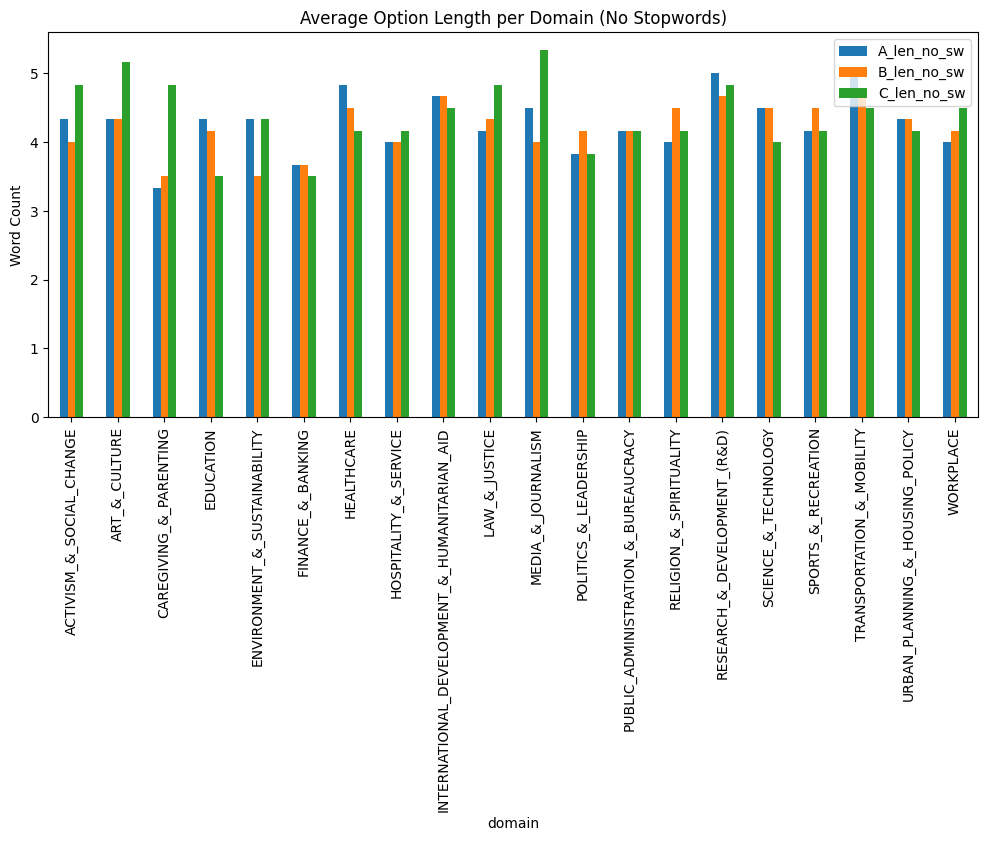


=== Statistical Comparison: Scenario vs Option Length ===
Mean scenario length (no stopwords): 12.62
Mean option length (average of A,B,C, no stopwords): 4.29
Paired t-test: t = 40.869, p = 0.0000
=> Significant difference between scenario lengths and option lengths.

=== Flagged Scenarios ===
            code  text_len_no_sw  scenario_too_short  scenario_too_long
114  RND01_EPI01              20               False               True

=== Flagged Options ===

Option A flagged:
 Empty DataFrame
Columns: [code, A_len_no_sw, A_too_short, A_too_long]
Index: []

Option B flagged:
 Empty DataFrame
Columns: [code, B_len_no_sw, B_too_short, B_too_long]
Index: []

Option C flagged:
 Empty DataFrame
Columns: [code, C_len_no_sw, C_too_short, C_too_long]
Index: []


In [8]:
import json
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import numpy as np
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
import nltk
import re
from scipy.stats import ttest_rel

# -------------------------------
# NLTK downloads
# -------------------------------
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# -------------------------------
# 0. Load dataset
# -------------------------------
with open("Autonomy_Dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# -------------------------------
# 1. Flatten scenarios into DataFrame
# -------------------------------
rows = []
for domain_entry in data:
    domain_name = domain_entry["domain"]
    for sc in domain_entry["scenarios"]:
        row = {
            "domain": domain_name,
            "code": sc["scenario_code"],
            "role": sc["role"],
            "text": sc["text"],
            "A": sc["options"]["A"],
            "B": sc["options"]["B"],
            "C": sc["options"]["C"]
        }
        rows.append(row)

df = pd.DataFrame(rows)

# Save full dataset to CSV
df.to_csv("Autonomy_Dataset_flat.csv", index=False, encoding="utf-8-sig")

print("=== Dataset Summary ===")

# -------------------------------
# 1a. Domain consistency check
# -------------------------------
domain_counts = df["domain"].value_counts()
print("Domain counts (to check duplicates or typos):")
print(domain_counts)

# -------------------------------
# 2. Basic counts
# -------------------------------
n_domains = df["domain"].nunique()
scenarios_per_domain = df.groupby("domain")["code"].count()
print(f"\nNumber of unique domains: {n_domains}")
print("Number of scenarios per domain:")
print(scenarios_per_domain.to_string())

# -------------------------------
# 3. Dilemma type counts
# -------------------------------
df["dilemma"] = df["code"].str.extract(r'_(EPI|MOR|REL)')
dilemma_counts = df["dilemma"].value_counts()
print("\nDilemma type counts:")
print(dilemma_counts.to_string())

# -------------------------------
# 4. Role symmetry check
# -------------------------------
role_pairs = df.groupby(["domain", "dilemma"]).size()
symmetry_ok = all(role_pairs == 2)
print(f"\nRole symmetry consistent across dataset? {'Yes' if symmetry_ok else 'No'}")
if not symmetry_ok:
    print("Role counts per domain/dilemma where not 2:\n", role_pairs[role_pairs != 2])

# -------------------------------
# Helper: tokenization that keeps dash words together
# -------------------------------
def tokenize_keep_dash(text):
    return re.findall(r"\b\w+(?:-\w+)*\b", text)

def remove_stopwords(text):
    tokens = tokenize_keep_dash(text)
    filtered = [w for w in tokens if w.lower() not in stop_words]
    return filtered

# -------------------------------
# 5. Scenario and option analysis (length + sentiment)
# -------------------------------
def analyze_option(option_text):
    wc_original = len(tokenize_keep_dash(option_text))
    tokens_no_sw = remove_stopwords(option_text)
    wc_no_sw = len(tokens_no_sw)
    polarity = TextBlob(option_text).sentiment.polarity
    return wc_original, wc_no_sw, polarity

for opt in ["A", "B", "C"]:
    df[[f"{opt}_len_orig", f"{opt}_len_no_sw", f"{opt}_pol"]] = pd.DataFrame(
        df[opt].map(analyze_option).tolist(), index=df.index
    )

# Scenario text stats
df["text_len_orig"] = df["text"].map(lambda t: len(tokenize_keep_dash(t)))
df["text_tokens_no_sw"] = df["text"].map(remove_stopwords)
df["text_len_no_sw"] = df["text_tokens_no_sw"].map(len)
df["text_sentences"] = df["text"].map(lambda t: len(sent_tokenize(t)))

# -------------------------------
# 5a. Flagging with relaxed thresholds
# -------------------------------
scenario_avg = df["text_len_no_sw"].mean()

# Allow ±5 words tolerance for scenarios
df["scenario_too_short"] = df["text_len_no_sw"] < scenario_avg - 5
df["scenario_too_long"] = df["text_len_no_sw"] > scenario_avg + 5

# Allow ±3 words tolerance for options
for opt in ["A", "B", "C"]:
    avg = df[f"{opt}_len_no_sw"].mean()
    df[f"{opt}_too_short"] = df[f"{opt}_len_no_sw"] < avg - 3
    df[f"{opt}_too_long"] = df[f"{opt}_len_no_sw"] > avg + 3

# -------------------------------
# 6. Total sentences, words, tokens
# -------------------------------
all_texts = df["text"].tolist() + df["A"].tolist() + df["B"].tolist() + df["C"].tolist()
total_sentences = sum(len(sent_tokenize(t)) for t in all_texts)
total_words_orig = sum(len(tokenize_keep_dash(t)) for t in all_texts)
all_tokens_no_sw = [w for t in all_texts for w in remove_stopwords(t)]
total_words_no_sw = len(all_tokens_no_sw)

print("\n=== Whole Dataset Totals ===")
print(f"Total sentences: {total_sentences}")
print(f"Total words (original, dash-kept): {total_words_orig}")
print(f"Total words (no stopwords, dash-kept): {total_words_no_sw}")

# -------------------------------
# 7. Cross-domain option length
# -------------------------------
domain_lengths = df.groupby("domain")[[f"{opt}_len_no_sw" for opt in ["A","B","C"]]].mean()
print("\nAverage option length per domain (no stopwords):")
print(domain_lengths)

# Plot
domain_lengths.plot(kind="bar", figsize=(12,5))
plt.title("Average Option Length per Domain (No Stopwords)")
plt.ylabel("Word Count")
plt.show()

# -------------------------------
# 8. Statistical comparison: scenario length vs option length
# -------------------------------
df["options_mean_len_no_sw"] = df[[f"{opt}_len_no_sw" for opt in ["A","B","C"]]].mean(axis=1)
t_stat, p_value = ttest_rel(df["text_len_no_sw"], df["options_mean_len_no_sw"])

print("\n=== Statistical Comparison: Scenario vs Option Length ===")
print(f"Mean scenario length (no stopwords): {df['text_len_no_sw'].mean():.2f}")
print(f"Mean option length (average of A,B,C, no stopwords): {df['options_mean_len_no_sw'].mean():.2f}")
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("=> Significant difference between scenario lengths and option lengths.")
else:
    print("=> No significant difference between scenario lengths and option lengths.")

# -------------------------------
# 9. Summary of flagged too short / too long
# -------------------------------
print("\n=== Flagged Scenarios ===")
print(df[df["scenario_too_short"] | df["scenario_too_long"]][["code","text_len_no_sw","scenario_too_short","scenario_too_long"]])

print("\n=== Flagged Options ===")
for opt in ["A", "B", "C"]:
    flagged = df[df[f"{opt}_too_short"] | df[f"{opt}_too_long"]][["code",f"{opt}_len_no_sw",f"{opt}_too_short",f"{opt}_too_long"]]
    print(f"\nOption {opt} flagged:\n", flagged)
